# **Business Understanding**


## THE CLIMATE CHANGE 

<img src="https://ocw.mit.edu/courses/cms-631-data-storytelling-studio-climate-change-spring-2017/6a102252006ddb7f4bc6e80ad8e90199_cms-631s17.gif"     alt="Historical Temperature Change"     style="float: left; margin-right: 50px;width:300px;height:300px;" />


Climate change is one of the important issues that face the world in this technological era. The best proof of this situation is the historical temperature change (It is shown in left figure[⁴](https://ocw.mit.edu/courses/comparative-media-studies-writing/cms-631-data-storytelling-studio-climate-change-spring-2017/#)).  Our project investigates the reality of the increase in temperatures linked to industrial activities and the greenhouse effect. And before this investigation, the aim of this part enlight the significant sides of the temperature change data for each area. Before beginning the analysis, firstly, I want to figure out our problem, its cause and its effects in a short way. 
 
 #### What is Climate Change?
 
"_Climate change is a long-term change in the average weather patterns that have come to define Earth’s local, regional and global climates. Changes observed in Earth’s climate since the early 20th century are primarily driven by human activities, particularly fossil fuel burning, which increases heat-trapping greenhouse gas levels in Earth’s atmosphere, raising Earth’s average surface temperature. These human-produced temperature increases are commonly referred to as global warming._[⁵](https://climate.nasa.gov/resources/global-warming-vs-climate-change/)"
 
 ##### Causes
According to NASA, Water Vapour, Carbon dioxide(CO₂), Methane, Nitrous oxide, Chlorofluorocarbons(CFCs) contribute to the greenhouse effect. Over the last century, human activities have increased concentrations of this natural greenhouse.
 
 ##### Effects:

"_Global climate change has already had observable effects on the environment. Glaciers have shrunk, ice on rivers and lakes is breaking up earlier, plant and animal ranges have shifted, and trees are flowering sooner. Effects that scientists had predicted in the past would result from global climate change: loss of sea ice accelerated sea-level rise and longer, more intense heat waves._[⁶](https://climate.nasa.gov/effects/)"


[Reference](https://www.kaggle.com/code/sevgisarac/climate-change#Guiding-Questions)
[Data Source](https://www.fao.org/faostat/en/#data/ET)

#### **Load Libraries**

In [54]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

#### **Load Data**

In [3]:
climate_df = pd.read_csv("data/FAOSTAT_data_en_3-11-2026.csv")

# **Data Understanding**
- head...tail (glimpse of the data)
- shape/ dimensions
- columns
- info
- missing values
- outliers
- duplicates
- descriptive stats(numerical and categorical)
- basic visualizations

#### **Glimpse of the data**

In [4]:
climate_df.head(4)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Months Code,Months,Year Code,Year,Unit,Value,Flag,Flag Description
0,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,2022,2022,°c,2.297,E,Estimated value
1,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,2023,2023,°c,-2.418,E,Estimated value
2,ET,Temperature change on land,4,Afghanistan,6078,Standard Deviation,7001,January,2022,2022,°c,1.964,E,Estimated value
3,ET,Temperature change on land,4,Afghanistan,6078,Standard Deviation,7001,January,2023,2023,°c,1.964,E,Estimated value


In [5]:
climate_df.tail(4)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Months Code,Months,Year Code,Year,Unit,Value,Flag,Flag Description
16180,ET,Temperature change on land,716,Zimbabwe,7271,Temperature change,7020,Meteorological year,2022,2022,°c,0.494,E,Estimated value
16181,ET,Temperature change on land,716,Zimbabwe,7271,Temperature change,7020,Meteorological year,2023,2023,°c,1.009,E,Estimated value
16182,ET,Temperature change on land,716,Zimbabwe,6078,Standard Deviation,7020,Meteorological year,2022,2022,°c,0.311,E,Estimated value
16183,ET,Temperature change on land,716,Zimbabwe,6078,Standard Deviation,7020,Meteorological year,2023,2023,°c,0.311,E,Estimated value


#### **Dimensions**

In [7]:
records,features = climate_df.shape
output = f"Data set is composed of {records} records and {features} features"
print(output)

Data set is composed of 16184 records and 14 features


#### **info, data types, columns**

In [8]:
climate_df.info

<bound method DataFrame.info of       Domain Code                      Domain  Area Code (M49)         Area  \
0              ET  Temperature change on land                4  Afghanistan   
1              ET  Temperature change on land                4  Afghanistan   
2              ET  Temperature change on land                4  Afghanistan   
3              ET  Temperature change on land                4  Afghanistan   
4              ET  Temperature change on land                4  Afghanistan   
...           ...                         ...              ...          ...   
16179          ET  Temperature change on land              716     Zimbabwe   
16180          ET  Temperature change on land              716     Zimbabwe   
16181          ET  Temperature change on land              716     Zimbabwe   
16182          ET  Temperature change on land              716     Zimbabwe   
16183          ET  Temperature change on land              716     Zimbabwe   

       Element Code

In [9]:
climate_df.dtypes

Domain Code             str
Domain                  str
Area Code (M49)       int64
Area                    str
Element Code          int64
Element                 str
Months Code           int64
Months                  str
Year Code             int64
Year                  int64
Unit                    str
Value               float64
Flag                    str
Flag Description        str
dtype: object

In [10]:
climate_df.columns

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Months Code', 'Months', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description'],
      dtype='str')

#### **duplicates, null values, outliers**

In [11]:
climate_df.duplicated().sum()

np.int64(0)

In [16]:
climate_df.isnull().sum() * 100 / len(climate_df) # calcluates the % missing values

Domain Code         0.000000
Domain              0.000000
Area Code (M49)     0.000000
Area                0.000000
Element Code        0.000000
Element             0.000000
Months Code         0.000000
Months              0.000000
Year Code           0.000000
Year                0.000000
Unit                0.000000
Value               6.043005
Flag                0.000000
Flag Description    0.000000
dtype: float64

Insight: the % of missing values in the 'Value" columnis approx at 6% hence we can drop the missing values, the remedy to this is dropping the missing values

#### **filtering dataset wehere element == 'temperture change'**

In [36]:
climate_df_2 = climate_df.loc[climate_df['Element']=='Temperature change'] # 

#### **Drop Null values - remedy to missing values**

In [37]:
cleaned_climate_df = climate_df_2.dropna()

In [38]:
cleaned_climate_df.isnull().sum() * 100 / len(cleaned_climate_df) # zero missing values

Domain Code         0.0
Domain              0.0
Area Code (M49)     0.0
Area                0.0
Element Code        0.0
Element             0.0
Months Code         0.0
Months              0.0
Year Code           0.0
Year                0.0
Unit                0.0
Value               0.0
Flag                0.0
Flag Description    0.0
dtype: float64

#### **Descriptive Stats(categorical and numerical)**

In [39]:
climate_df_2.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Months Code,Months,Year Code,Year,Unit,Value,Flag,Flag Description
0,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,2022,2022,°c,2.297,E,Estimated value
1,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,2023,2023,°c,-2.418,E,Estimated value
4,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7002,February,2022,2022,°c,2.357,E,Estimated value
5,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7002,February,2023,2023,°c,3.478,E,Estimated value
8,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7003,March,2022,2022,°c,3.547,E,Estimated value


In [40]:
cleaned_climate_df = cleaned_climate_df.drop(['Area Code (M49)','Element Code','Months Code','Year Code'], axis=1)

In [41]:
cleaned_climate_df.describe()

,Year,Value
count,7686.000000,7686.000000
mean,2022.498829,1.537879
std,0.500031,1.091926
min,2022.000000,-2.832000
25%,2022.000000,0.851250
50%,2022.000000,1.373000
75%,2023.000000,2.096000
max,2023.000000,10.200000


In [42]:
cleaned_climate_df.describe(include='object')

/tmp/ipykernel_12973/3061419096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cleaned_climate_df.describe(include='object')


,Domain Code,Domain,Area,Element,Months,Unit,Flag,Flag Description
count,7686,7686,7686,7686,7686,7686,7686,7686
unique,1,1,228,1,17,1,1,1
top,ET,Temperature change on land,Afghanistan,Temperature change,March,°c,E,Estimated value
freq,7686,7686,34,7686,454,7686,7686,7686


In [43]:
cleaned_climate_df['Months'].unique()

<StringArray>
[            'January',            'February',               'March',
               'April',                 'May',                'June',
                'July',              'August',           'September',
             'October',            'November',            'December',
         'Dec–Jan–Feb',         'Mar–Apr–May',         'Jun–Jul–Aug',
         'Sep–Oct–Nov', 'Meteorological year']
Length: 17, dtype: str

#### **Normal Distribution**

In [44]:
cleaned_climate_df.head(3)

,Domain Code,Domain,Area,Element,Months,Year,Unit,Value,Flag,Flag Description
0,ET,Temperature change on land,Afghanistan,Temperature change,January,2022,°c,2.297,E,Estimated value
1,ET,Temperature change on land,Afghanistan,Temperature change,January,2023,°c,-2.418,E,Estimated value
4,ET,Temperature change on land,Afghanistan,Temperature change,February,2022,°c,2.357,E,Estimated value


In [45]:
values = cleaned_climate_df['Value']
values

0        2.297
1       -2.418
4        2.357
5        3.478
8        3.547
         ...  
16173    1.293
16176    0.866
16177    1.736
16180    0.494
16181    1.009
Name: Value, Length: 7686, dtype: float64

In [46]:
values.describe()

count    7686.000000
mean        1.537879
std         1.091926
min        -2.832000
25%         0.851250
50%         1.373000
75%         2.096000
max        10.200000
Name: Value, dtype: float64

In [52]:
# MCTs
mean = np.mean(values) 
median = np.median(values)
mode = values.mode()[0]
output = f"MEAN: {mean} || MODE: {mode} || MEDIAN: {median}"
print(output) 

MEAN: 1.5378791308873274 || MODE: 0.812 || MEDIAN 1.373
0.812


In [53]:
# MoVs
sd = np.std(values) 
variance = np.var(values)
range_of_values = np.max(values) - np.min(values) 
output = f"VARIANCE: {variance} || STANDARD DEVIATION: {sd} || RANGE: {range_of_values}"
print(output) 

VARIANCE: 1.192146826530392 || STANDARD DEVIATION: 1.0918547643942358 || RANGE: 13.032


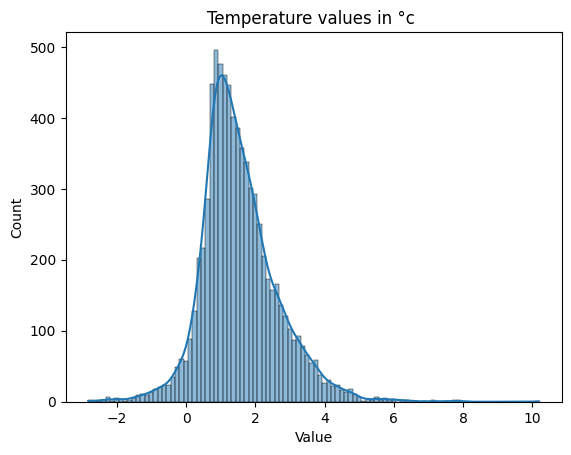

In [55]:
sns.histplot(values, kde=True)
plt.title("Temperature values in °c ")
plt.show()


In [62]:
values.shape

(7686,)

In [56]:
#load 
climate_large_df = pd.read_csv('data/FAOSTAT_data_en_3-11-2026_large.csv')

In [57]:
climate_large_df.isnull().sum()/len(cleaned_climate_df)

Domain Code         0.000000
Domain              0.000000
Area Code (M49)     0.000000
Area                0.000000
Element Code        0.000000
Element             0.000000
Months Code         0.000000
Months              0.000000
Year Code           0.000000
Year                0.000000
Unit                0.000000
Value               0.108249
Flag                0.000000
Flag Description    0.000000
dtype: float64

In [58]:
cleaned_climate_large_df = climate_large_df.dropna(axis=0)

In [59]:
cleaned_climate_large_df.isnull().sum()/len(cleaned_climate_large_df)

Domain Code         0.0
Domain              0.0
Area Code (M49)     0.0
Area                0.0
Element Code        0.0
Element             0.0
Months Code         0.0
Months              0.0
Year Code           0.0
Year                0.0
Unit                0.0
Value               0.0
Flag                0.0
Flag Description    0.0
dtype: float64

In [60]:
cleaned_climate_large_df.shape

(15352, 14)

In [66]:
large_values.describe()

count    15352.000000
mean         1.477878
std          1.052964
min         -3.966000
25%          0.866000
50%          1.338000
75%          1.955250
max         10.200000
Name: Value, dtype: float64

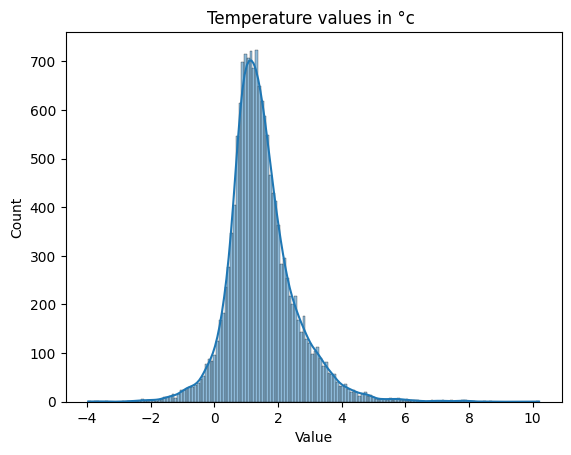

In [61]:
large_values = cleaned_climate_large_df['Value']

# plot
sns.histplot(large_values, kde=True)
plt.title("Temperature values in °c ")
plt.show()

In [63]:
large_values.shape

(15352,)

In [65]:
large_values.shape

(15352,)

#### **Insights:**

- This analyais focused on estimated Temperature Change in °cover period of months in diffrence Areas

We started of with a datasize of **7,686 records**
- Intially the data was composed of missing values in the Values column (6% missing values). The remedy was to drop the records containing missing values

- The average temperature change was at 1.538 ° with data focusingon the year 2022 & 2023

- The highest temperature change was at 10 °c	and lowest was t -2.832 °c, with 25% of the temperature changes falling below 0.8512°c	, most of the data(50%) fell around 1.373°c	and finally 75% of the readings fell below 2.096°c

- The data was approximately normally distributed, however it was skewed to the right:

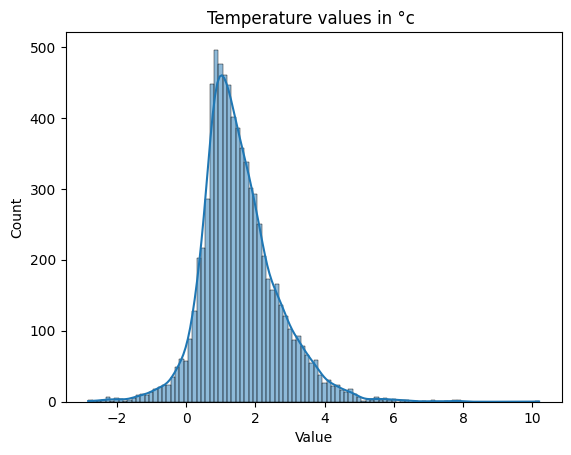

<hr>

Transitioning to **15,352 records**
- Intially the data was composed of missing values in the Values column (0.1% missing values). The remedy was to drop the records containing missing values

- The average temperature change was at 1.538 ° with data focusingon the year 2021 to 2023

- The highest temperature change was at 10.2 °c	and lowest was t -3.966°c, with 25% of the temperature changes falling below 0.866°c	, most of the data(50%) fell around 1.338°c	and finally 75% of the readings fell below 1.955°c

- The data was approximately normally distributed, however the skewness reduced as the ata set increased in size

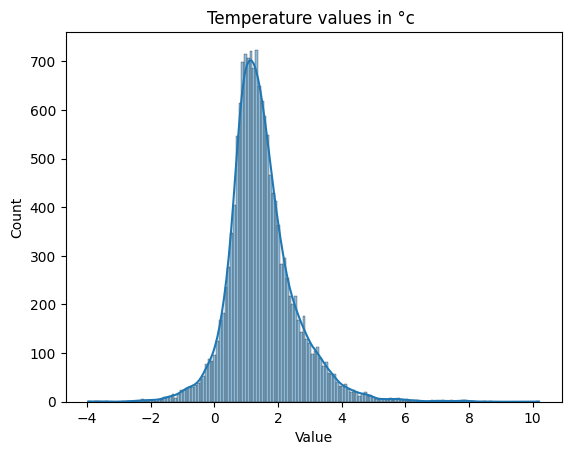

